## **Logistic Regression**
-Dhairya

 A dataset contains the academic records of a group of students, capturing two independent variables: Attendance (in %) and the Number of Hours studied. The dependent variable is binary, where $Y=1$ indicates the student passed the exam, and $Y=0$ indicates the student failed.Formulate a classification model using these two features to predict whether a new student will pass or fail the exam. Which algorithm would you choose, and how would you evaluate its performance?

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

       Hours  Attendance  Pass
0  -0.092039   90.462482     0
1   6.738064   86.285600     1
2   7.422917  102.048667     1
3  10.215400   93.255619     1
4   0.759276   40.701531     0


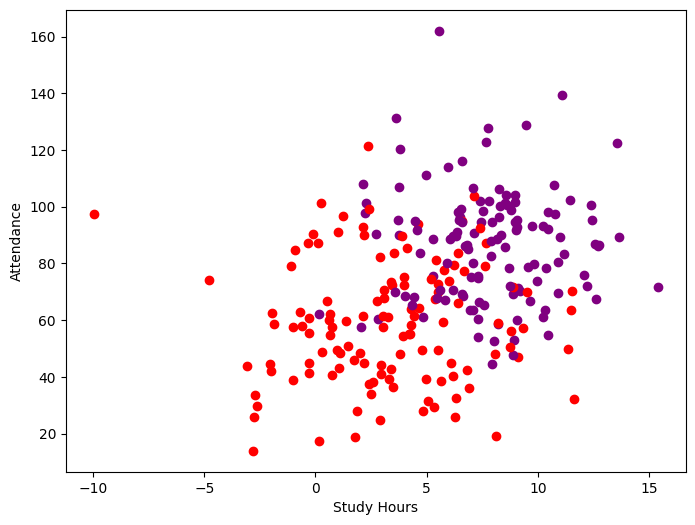

In [ ]:
np.random.seed(42)

n = 250

h1 = np.random.normal(8, 3, n // 2)
a1 = np.random.normal(85, 20, n // 2)

h0 = np.random.normal(3, 4, n // 2)
a0 = np.random.normal(60, 20, n // 2)

h = np.concatenate([h1, h0])
a = np.concatenate([a1, a0])

y = np.array([1] * (n // 2) + [0] * (n // 2))

p = np.random.permutation(n)

h = h[p]
a = a[p]
y = y[p]

df = pd.DataFrame({
    "Hours": h,
    "Attendance": a,
    "Pass": y
})

print(df.head())

plt.figure(figsize=(8,6))

for i in range(n):
    if y[i] == 1:
        plt.scatter(h[i], a[i], color='purple')
    else:
        plt.scatter(h[i], a[i], color='red')

plt.xlabel("Study Hours")
plt.ylabel("Attendance")

plt.show()

In [ ]:
X=df.iloc[:,0:2]
Y=df.iloc[:,-1]
print(Y)

0      0
1      1
2      1
3      1
4      0
      ..
245    0
246    0
247    0
248    1
249    1
Name: Pass, Length: 250, dtype: int64


In [ ]:
m=np.mean(X,axis=0)
s=np.std(X,axis=0)
X=(X-m)/s
print(X)

        Hours  Attendance
0   -1.424704    0.713476
1    0.306957    0.544584
2    0.480590    1.181961
3    1.188579    0.826416
4   -1.208867   -1.298599
..        ...         ...
245 -0.085937    0.062005
246  0.473540    0.798786
247 -0.325466   -0.719663
248 -0.282935   -0.192198
249  0.711268    0.695174

[250 rows x 2 columns]


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=42)
print(X_train.shape)
print(X_test.shape)

(187, 2)
(63, 2)


In [ ]:
from sklearn.linear_model import LogisticRegression
l = LogisticRegression()
l.fit(X_train, Y_train)

LogisticRegression()

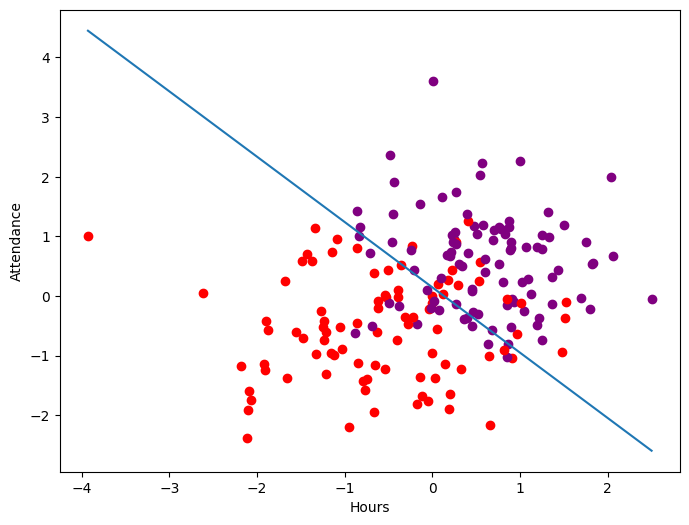

In [ ]:
plt.figure(figsize=(8,6))
for i in range(len(Y_train)):
    if Y.iloc[i] == 1:
        plt.scatter(X.iloc[i, 0], X.iloc[i, 1], color='purple')
    else:
        plt.scatter(X.iloc[i, 0], X.iloc[i, 1], color='red')
w = l.coef_[0]
b = l.intercept_[0]
x1 = np.linspace(X.iloc[:,0].min(), X.iloc[:,0].max(), 100)
x2 = -(w[0] * x1 + b) / w[1]
plt.plot(x1, x2)
plt.xlabel("Hours")
plt.ylabel("Attendance")
plt.show()

[[102  23]
 [ 24 101]]


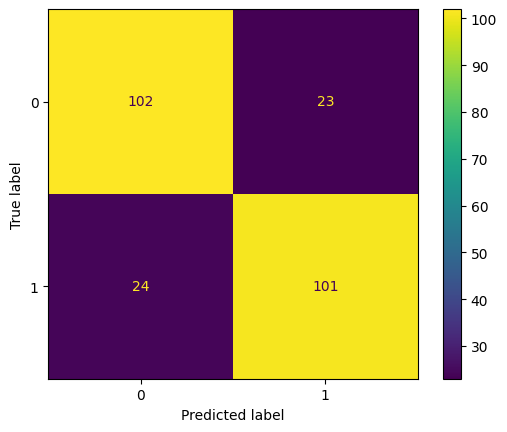

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_pred = l.predict(X)
cm = confusion_matrix(Y, y_pred)
print(cm)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.show()

In [ ]:
import sklearn.metrics as metrics
cr=metrics.classification_report(Y,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.81      0.82      0.81       125
           1       0.81      0.81      0.81       125

    accuracy                           0.81       250
   macro avg       0.81      0.81      0.81       250
weighted avg       0.81      0.81      0.81       250

